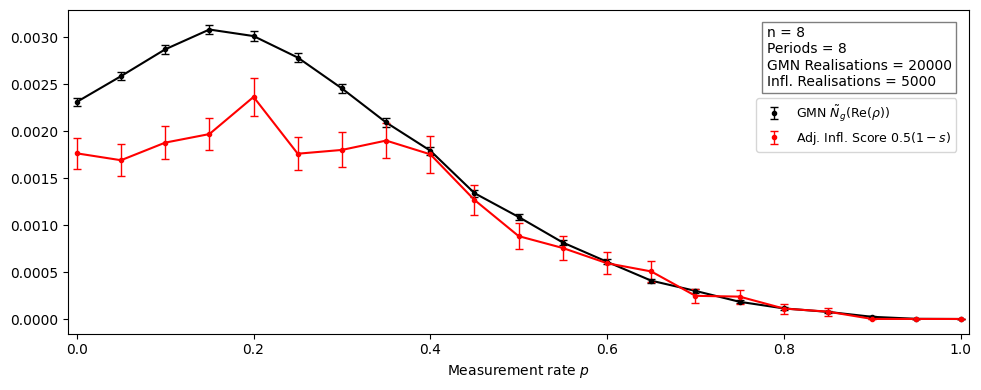

In [6]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt


# infl_reals = 5000

# # import GMN data
# df = pd.read_csv('data.csv')
# data_array = df.to_numpy().transpose()
# gmn_ps = data_array[0]
# gmn_vals = data_array[1]

# # import GMN/circuit info
# df2 = pd.read_csv('info.csv')
# data_array2 = df2.to_numpy().transpose()
# n = int(data_array2[0][0])
# periods = int(data_array2[1][0])
# realizations = int(data_array2[2][0])
# res = int(data_array2[3][0])
# p_min = float(data_array2[4][0])
# p_max = float(data_array2[5][0])

# # import inflation data
# df3 = pd.read_csv('cpp/inflation_n_8_real_5k_all.csv')
# data_array3 = df3.to_numpy().transpose()
# infl_ps = data_array3[0]
# # i_gmn_vals = data_array3[1]
# infl_scores = data_array3[2]



# # get means +/- stds for real GMN
# ps_unique = list(set(gmn_ps))
# gmn_means = []
# gmn_stds = []
# for p in ps_unique:
#     values_for_p = [val for val, p_val in zip(gmn_vals, gmn_ps) if p_val == p]
#     gmn_means.append(np.mean(values_for_p))
#     gmn_stds.append(np.std(values_for_p, ddof=1)/np.sqrt(realizations*n))

# # get means +/- stds for inflation
# infl_ps_unique = list(set(infl_ps))
# infl_means = []
# infl_stds = []
# for p in infl_ps_unique:
#     infl_values_for_p = [infl for infl, p_val in zip(infl_scores, infl_ps) if p_val == p]
#     infl_means.append(np.mean(infl_values_for_p))
#     infl_stds.append(np.std(infl_values_for_p, ddof=1)/np.sqrt(infl_reals))

sorted_pairs = sorted(zip(ps_unique, gmn_means))
x_sorted, y_sorted = zip(*sorted_pairs)
# plot GMN
fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))
ax1.errorbar(ps_unique, gmn_means, yerr=gmn_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1, label=r"GMN $\tilde{N}_g(\text{Re}(\rho))$")
ax1.set_xlabel('Measurement rate $p$')
ax1.plot(x_sorted, y_sorted, color='black')
# ax1.set_ylabel(r'GMN $\tilde{N}_g(\rho)$ = $-\min\;\text{tr}\.(\rho W)$')

sorted_pairs = sorted(zip(infl_ps_unique, infl_means))
x_sorted, y_sorted = zip(*sorted_pairs)
# plot inflation
scale = 0.5
ax1.errorbar(infl_ps_unique, [scale*(1 - m) for m in infl_means], yerr=scale*np.array(infl_stds), 
             fmt='.', color='red', ecolor='red', capsize=3, elinewidth=1, label=f"Adj. Infl. Score ${scale}(1-s)$")
ax1.plot(x_sorted, [scale*(1-m) for m in y_sorted], color='red')


props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.775, 0.95, f"n = {n}\nPeriods = {periods}\nGMN Realisations = {realizations}\nInfl. Realisations = {infl_reals}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax1.set_xlim(-0.01,1.01)

fig.legend(bbox_to_anchor=(0.9675, 0.675), loc="center right", fontsize=9)
fig.tight_layout()

In [ ]:
from mipt import *
import numpy as np

from mipt_rho3_bin_writer import Rho3BinWriter, ring_subsystem_qubits

n = 8
d = 2 * n
ps = np.linspace(0.0, 1.0, 21)
realisations = 1000

subsystem_qubits = ring_subsystem_qubits(n, closed=True)

with Rho3BinWriter(
    "rho3_python_archA.bin",
    total_qubits=n,
    subsystem_qubits=subsystem_qubits,
    periods=d,
    realizations=realisations,
    p_vals=ps,
) as writer:
    for p_index, p in enumerate(ps):
        print(f"Simulating p = {p}...")
        for r in range(realisations):
            rhos = get_mipt_rho_1d(
                n, d, p,
                subsyst=3,
                all_matrices=True,
                closed=True,
            )

            writer.write_record(
                p_index=p_index,
                realization=r,
                p=float(p),
                rhos=rhos,
            )
            print(f"Realisations: {r}/{realisations}", end='\r', flush=True)
        print()

Simulating p = 0.0...
Realisations: 999/1000
Simulating p = 0.05...
Realisations: 999/1000
Simulating p = 0.1...


In [23]:
import numpy as np
print(np.linspace(0.13, 0.2, 15))
# d = 4
# print(list(range(0, 2*d+1, d)))

[0.13  0.135 0.14  0.145 0.15  0.155 0.16  0.165 0.17  0.175 0.18  0.185
 0.19  0.195 0.2  ]


Importing n = 12...
Importing n = 16...
Plotting...


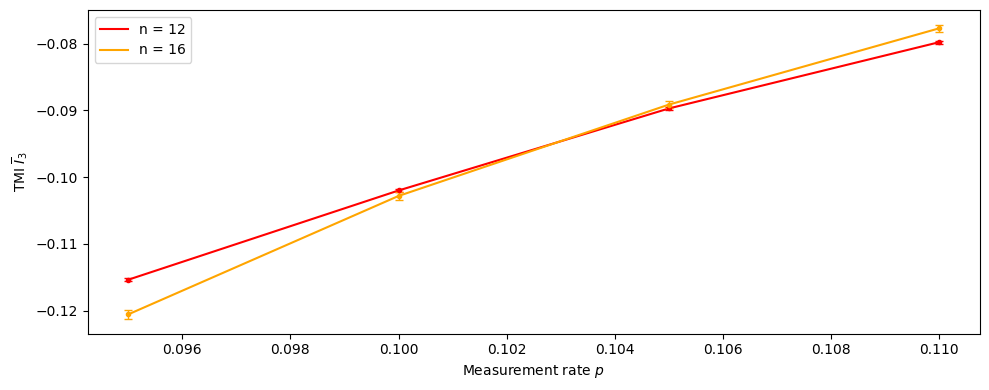

In [7]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# -----------------------
# User controls
# -----------------------
P_MIN = 0.095
P_MAX = 0.11

CHUNKSIZE = 1_000_000  # increase/decrease depending on RAM

# files = [
#     "csv/tmi/fermion2c/tmi_fermion2c_n_8_real_50k_0.1_0.5_res_81.csv",
#     "csv/tmi/fermion2c/tmi_fermion2c_n_12_real_25k_0.1_0.5.csv",
#     "csv/tmi/fermion2c/tmi_fermion2c_n_16_real_2500_0.1_0.5.csv",
#     "csv/tmi/fermion2c/tmi_fermion2c_n_20_real_250_0.1_0.5.csv",
# ]

files = [
    "tmi_fermion2c_n_12_real_100k_0.08_0.13.csv",
    "tmi_fermion2c_n_16_real_10k_0.08_0.13.csv"
]

ns = [12, 16]
colors = ["red", "orange", "green", "blue"]


def summarize_tmi_csv_once(path, p_min=None, p_max=None, chunksize=1_000_000):
    """
    Reads the CSV once in chunks and computes mean/std-error of tmi grouped by p.

    Expected CSV columns:
        p,tmi
    """

    partials = []

    for chunk in pd.read_csv(path, usecols=["p", "tmi"], chunksize=chunksize):
        if p_min is not None:
            chunk = chunk[chunk["p"] >= p_min]
        if p_max is not None:
            chunk = chunk[chunk["p"] <= p_max]

        if chunk.empty:
            continue

        grouped = chunk.groupby("p")["tmi"].agg(
            count="count",
            sum="sum",
            sumsq=lambda x: np.square(x).sum(),
        )

        partials.append(grouped)

    if not partials:
        return np.array([]), np.array([]), np.array([])

    combined = pd.concat(partials).groupby(level=0).sum().sort_index()

    count = combined["count"].to_numpy(dtype=float)
    total = combined["sum"].to_numpy(dtype=float)
    sumsq = combined["sumsq"].to_numpy(dtype=float)

    means = total / count

    # sample variance: (sum(x^2) - sum(x)^2 / n) / (n - 1)
    variances = np.full_like(means, np.nan, dtype=float)
    valid = count > 1
    variances[valid] = (sumsq[valid] - total[valid] ** 2 / count[valid]) / (count[valid] - 1)

    stds = np.sqrt(np.maximum(variances, 0.0))
    stderrs = stds / np.sqrt(count)

    ps = combined.index.to_numpy(dtype=float)

    return ps, means, stderrs


ps_arr, mean_arr, std_arr = [], [], []

for n, path in zip(ns, files):
    print(f"Importing n = {n}...")
    ps, means, stderrs = summarize_tmi_csv_once(
        path,
        p_min=P_MIN,
        p_max=P_MAX,
        chunksize=CHUNKSIZE,
    )

    ps_arr.append(ps)
    mean_arr.append(means)
    std_arr.append(stderrs)

print("Plotting...")

fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))

for i, n in enumerate(ns):
    ax1.errorbar(
        ps_arr[i],
        mean_arr[i],
        yerr=std_arr[i],
        fmt=".",
        color=colors[i],
        ecolor=colors[i],
        capsize=3,
        elinewidth=1,
    )

    ax1.plot(
        ps_arr[i],
        mean_arr[i],
        color=colors[i],
        label=f"n = {n}",
    )

ax1.set_xlabel(r"Measurement rate $p$")
ax1.set_ylabel(r"TMI $\overline{I}_3$")
ax1.legend()
fig.tight_layout()
plt.show()

Importing n = 16...
Plotting...


/tmp/ipykernel_6686/3308862456.py:124: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


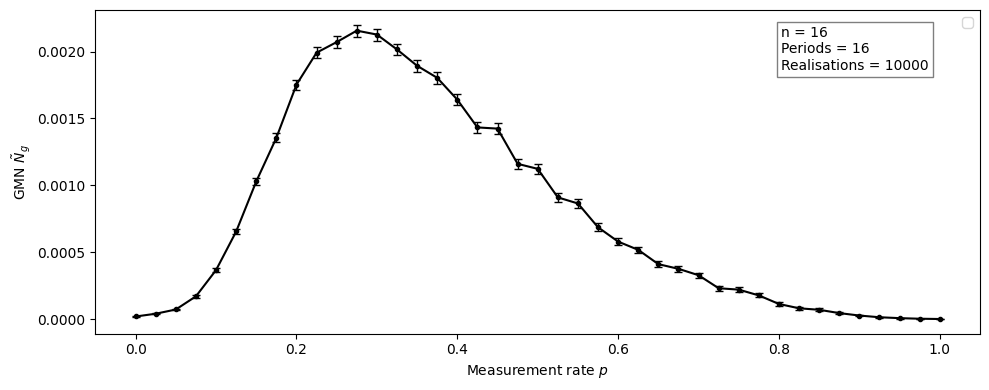

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# -----------------------
# User controls
# -----------------------
P_MIN = 0.0
P_MAX = 1.0

CHUNKSIZE = 1_000_000  # increase/decrease depending on RAM

# files = [
#     "csv/tmi/fermion2c/tmi_fermion2c_n_8_real_50k_0.1_0.5_res_81.csv",
#     "csv/tmi/fermion2c/tmi_fermion2c_n_12_real_25k_0.1_0.5.csv",
#     "csv/tmi/fermion2c/tmi_fermion2c_n_16_real_2500_0.1_0.5.csv",
#     "csv/tmi/fermion2c/tmi_fermion2c_n_20_real_250_0.1_0.5.csv",
# ]

files = [
    "gmn_n_16_real_10k.csv"
]

ns = [16]
colors = ["black", "red", "orange", "green", "blue"]


def summarize_tmi_csv_once(path, p_min=None, p_max=None, chunksize=1_000_000):
    """
    Reads the CSV once in chunks and computes mean/std-error of tmi grouped by p.

    Expected CSV columns:
        p,tmi
    """

    partials = []

    for chunk in pd.read_csv(path, usecols=["p", "gmn"], chunksize=chunksize):
        if p_min is not None:
            chunk = chunk[chunk["p"] >= p_min]
        if p_max is not None:
            chunk = chunk[chunk["p"] <= p_max]

        if chunk.empty:
            continue

        grouped = chunk.groupby("p")["gmn"].agg(
            count="count",
            sum="sum",
            sumsq=lambda x: np.square(x).sum(),
        )

        partials.append(grouped)

    if not partials:
        return np.array([]), np.array([]), np.array([])

    combined = pd.concat(partials).groupby(level=0).sum().sort_index()

    count = combined["count"].to_numpy(dtype=float)
    total = combined["sum"].to_numpy(dtype=float)
    sumsq = combined["sumsq"].to_numpy(dtype=float)

    means = total / count

    # sample variance: (sum(x^2) - sum(x)^2 / n) / (n - 1)
    variances = np.full_like(means, np.nan, dtype=float)
    valid = count > 1
    variances[valid] = (sumsq[valid] - total[valid] ** 2 / count[valid]) / (count[valid] - 1)

    stds = np.sqrt(np.maximum(variances, 0.0))
    stderrs = stds / np.sqrt(count)

    ps = combined.index.to_numpy(dtype=float)

    return ps, means, stderrs


ps_arr, mean_arr, std_arr = [], [], []

for n, path in zip(ns, files):
    print(f"Importing n = {n}...")
    ps, means, stderrs = summarize_tmi_csv_once(
        path,
        p_min=P_MIN,
        p_max=P_MAX,
        chunksize=CHUNKSIZE,
    )

    ps_arr.append(ps)
    mean_arr.append(means)
    std_arr.append(stderrs)

print("Plotting...")

fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))

for i, n in enumerate(ns):
    ax1.errorbar(
        ps_arr[i],
        mean_arr[i],
        yerr=std_arr[i],
        fmt=".",
        color=colors[i],
        ecolor=colors[i],
        capsize=3,
        elinewidth=1,
    )

    ax1.plot(
        ps_arr[i],
        mean_arr[i],
        color=colors[i],
    )

n = 16
periods = 16
realisations = 10_000
props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.775, 0.95, f"n = {n}\nPeriods = {periods}\nRealisations = {realisations}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

ax1.set_xlabel(r"Measurement rate $p$")
ax1.set_ylabel(r"GMN $\tilde{N}_g$")
ax1.legend()
fig.tight_layout()
plt.show()